# Human Resource Analytics: Enhancing Organizational Effectiveness through HR Analytics

## Overview

This HR Analytics project is designed to provide a holistic understanding of the organization by focusing on key areas. Objectives include analyzing current demographics and management structures, evaluating organizational performance, assessing employee satisfaction levels, and identifying and addressing counterproductive work behaviors. Through a combination of quantitative and qualitative methods, the project aims to deliver actionable insights to enhance overall organizational effectiveness and employee well-being.


## Objectives

1. Determine the current demographic and management structure of the organisation
2. Determine the level of organization performance
3. Determine the level of organization satisfaction
4. Determine the level of organization counterproductive work behaviour

## Part One: Understanding the Background and Data


**Content**

The CSV revolves around a fictitious company and the core data set contains names, DOBs, age, gender, marital status, date of hire, reasons for termination, department, whether they are active or terminated, position title, pay rate, manager name, and performance score.

Recent additions to the data include:

Absences

Most Recent Performance Review Date

Employee Engagement Score


**Acknowledgements**

Dr. Carla Patalano provided the baseline idea for creating this synthetic data set, which has been used now by over 200 Human Resource Management students at the college. Students in the course learn data visualization techniques with Tableau Desktop and use this data set to complete a series of assignments.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("/kaggle/input/human-resources-data-set/HRDataset_v14.csv")

**Information about the data and table example**

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 311 entries, 0 to 310
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Employee_Name               311 non-null    object 
 1   EmpID                       311 non-null    int64  
 2   MarriedID                   311 non-null    int64  
 3   MaritalStatusID             311 non-null    int64  
 4   GenderID                    311 non-null    int64  
 5   EmpStatusID                 311 non-null    int64  
 6   DeptID                      311 non-null    int64  
 7   PerfScoreID                 311 non-null    int64  
 8   FromDiversityJobFairID      311 non-null    int64  
 9   Salary                      311 non-null    int64  
 10  Termd                       311 non-null    int64  
 11  PositionID                  311 non-null    int64  
 12  Position                    311 non-null    object 
 13  State                       311 non

In [5]:
df.head()

,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,ManagerName,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
0,"Adinolfi, Wilson K",10026,0,0,1,1,5,4,0,62506,...,Michael Albert,22.0,LinkedIn,Exceeds,4.60,5,0,1/17/2019,0,1
1,"Ait Sidi, Karthikeyan",10084,1,1,1,5,3,3,0,104437,...,Simon Roup,4.0,Indeed,Fully Meets,4.96,3,6,2/24/2016,0,17
2,"Akinkuolie, Sarah",10196,1,1,0,5,5,3,0,64955,...,Kissy Sullivan,20.0,LinkedIn,Fully Meets,3.02,3,0,5/15/2012,0,3
3,"Alagbe,Trina",10088,1,1,0,1,5,3,0,64991,...,Elijiah Gray,16.0,Indeed,Fully Meets,4.84,5,0,1/3/2019,0,15
4,"Anderson, Carol",10069,0,2,0,5,5,3,0,50825,...,Webster Butler,39.0,Google Search,Fully Meets,5.00,4,0,2/1/2016,0,2


## Part Two: Exploratory Data Analysis

## Demographics

**Sex distribution in the organisation**

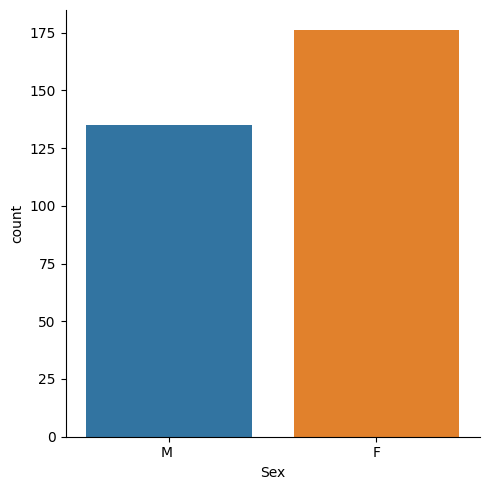

In [4]:
sns.catplot(x='Sex',kind='count',data=df)

**Ethnicity distribution in the organisation**

(array([0, 1, 2, 3, 4, 5]),
 [Text(0, 0, 'White'),
  Text(1, 0, 'Black or African American'),
  Text(2, 0, 'Two or more races'),
  Text(3, 0, 'Asian'),
  Text(4, 0, 'American Indian or Alaska Native'),
  Text(5, 0, 'Hispanic')])

<Figure size 2800x2000 with 0 Axes>

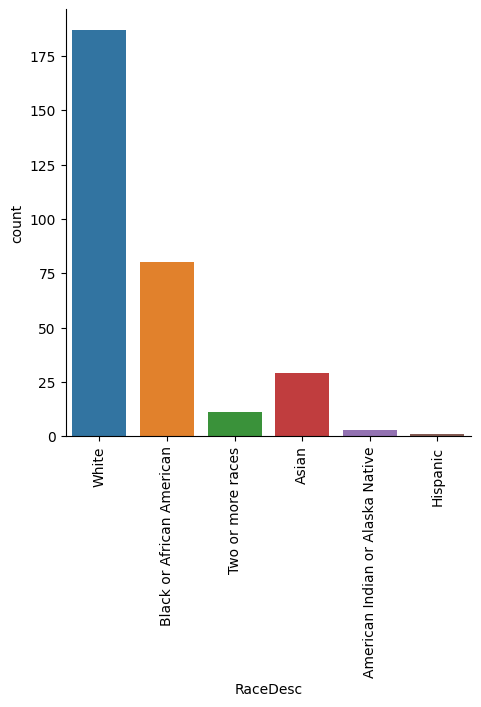

In [10]:
plt.figure(figsize=(14,10), dpi=200)
sns.catplot(x='RaceDesc',kind='count', data=df)
plt.xticks(rotation=90)

**Location-Based Distribution**

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27],
 [Text(0, 0, 'MA'),
  Text(1, 0, 'TX'),
  Text(2, 0, 'CT'),
  Text(3, 0, 'VA'),
  Text(4, 0, 'VT'),
  Text(5, 0, 'AL'),
  Text(6, 0, 'WA'),
  Text(7, 0, 'CA'),
  Text(8, 0, 'OH'),
  Text(9, 0, 'IN'),
  Text(10, 0, 'TN'),
  Text(11, 0, 'NH'),
  Text(12, 0, 'RI'),
  Text(13, 0, 'PA'),
  Text(14, 0, 'CO'),
  Text(15, 0, 'NY'),
  Text(16, 0, 'UT'),
  Text(17, 0, 'GA'),
  Text(18, 0, 'FL'),
  Text(19, 0, 'NC'),
  Text(20, 0, 'KY'),
  Text(21, 0, 'ID'),
  Text(22, 0, 'NV'),
  Text(23, 0, 'MT'),
  Text(24, 0, 'OR'),
  Text(25, 0, 'ND'),
  Text(26, 0, 'AZ'),
  Text(27, 0, 'ME')])

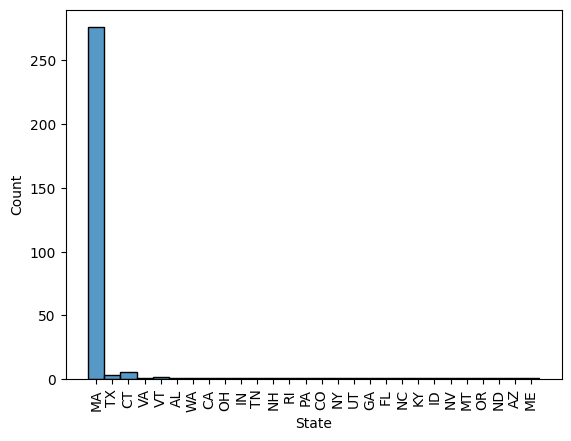

In [11]:
sns.histplot(data=df, x="State")
plt.xticks(rotation=90)

## Organisation structure

**Position Distribution Overview**

In [12]:
pd.DataFrame(df["Position"].value_counts())

,count
Position,
Production Technician I,137
Production Technician II,57
Area Sales Manager,27
Production Manager,14
Software Engineer,10
IT Support,8
Data Analyst,7
Sr. Network Engineer,5
Database Administrator,5


**How many managers organization have? How many subordinates does a manager have?**

In [83]:
managersN = len(df["ManagerID"].unique())
employee_counts = df['ManagerID'].value_counts()
print(f"There is {managersN} managers in total. Every manager have to manage {round(employee_counts.mean(), 2)} employees in average.")

There is 24 managers in total. Every manager have to manage 13.17 employees in average.


**How many managers are per department?**

In [39]:
managers_per_department = df.groupby('Department')['ManagerID'].nunique()
managers_per_department

Department
Admin Offices            4
Executive Office         1
IT/IS                    6
Production              11
Sales                    4
Software Engineering     3
Name: ManagerID, dtype: int64

**What is employees distribution across departments?**

(array([0, 1, 2, 3, 4, 5]),
 [Text(0, 0, 'Production       '),
  Text(1, 0, 'IT/IS'),
  Text(2, 0, 'Software Engineering'),
  Text(3, 0, 'Admin Offices'),
  Text(4, 0, 'Sales'),
  Text(5, 0, 'Executive Office')])

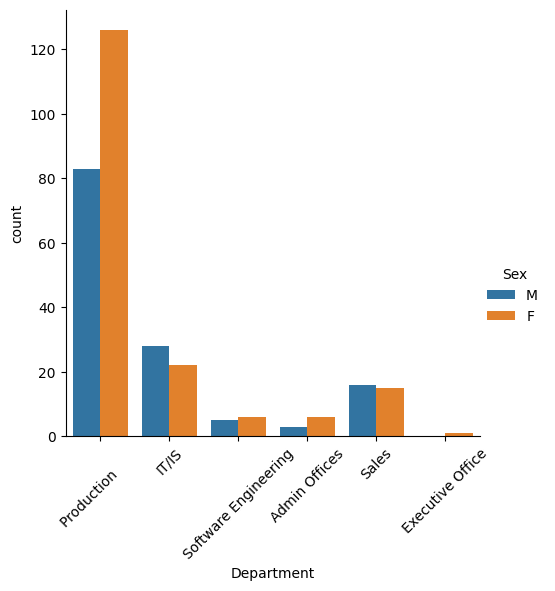

In [33]:
sns.catplot(x= 'Department',kind='count',data=df, hue="Sex")
plt.xticks(rotation=45)

## Organisation Performance

**What is the distribution of Performance Score in the organization?**

(array([0, 1, 2, 3]),
 [Text(0, 0, 'Exceeds'),
  Text(1, 0, 'Fully Meets'),
  Text(2, 0, 'Needs Improvement'),
  Text(3, 0, 'PIP')])

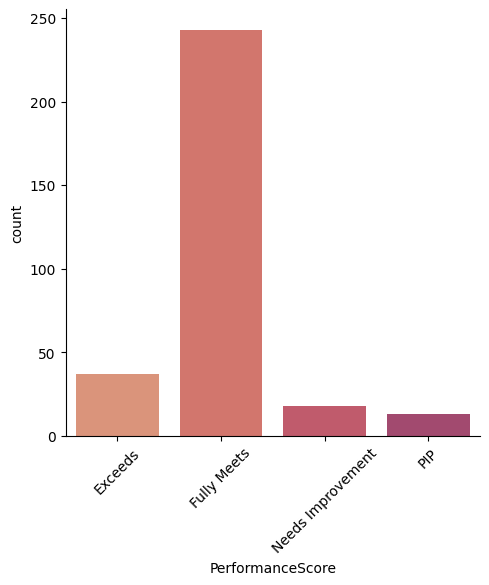

In [97]:
color_palette = sns.color_palette("flare")
sns.set_palette(color_palette)
sns.catplot(x = "PerformanceScore",kind='count', data = df)
plt.xticks(rotation=45)

(array([0, 1, 2, 3]),
 [Text(0, 0, 'Exceeds'),
  Text(1, 0, 'Fully Meets'),
  Text(2, 0, 'Needs Improvement'),
  Text(3, 0, 'PIP')])

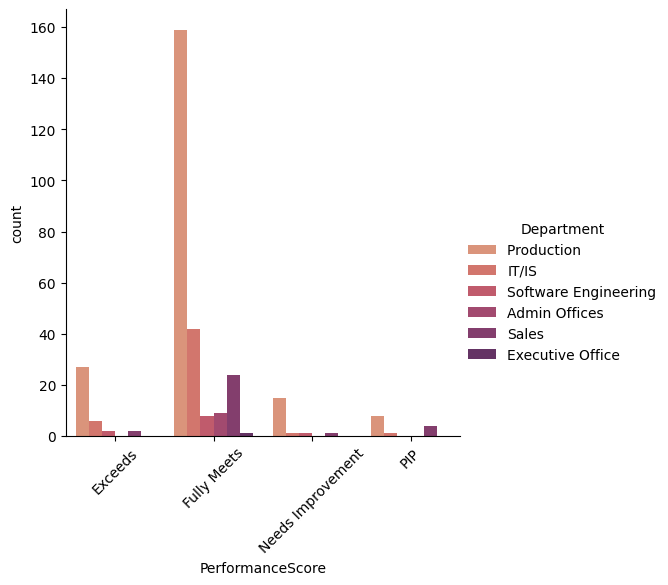

In [108]:
sns.catplot(x= 'PerformanceScore',kind='count',data=df, hue="Department")
plt.xticks(rotation=45)

Due to absolute count and unequal distributions of employees per depertment, performance score among departments can't be compared. Therefore, relative proportion, taking into account the relative number of employee per depertment, is calculated for better comparison.

In [59]:
# Calculate the percentage of each category within each department
percentages = df.groupby(['Department', 'PerformanceScore']).size().div(df.groupby('Department').size()).mul(100).reset_index(name='Percentage')
# Create a pivot table for better organization
pivot_table = pd.pivot_table(percentages, values='Percentage', index='PerformanceScore', columns='Department')
pivot_table


Department,Admin Offices,Executive Office,IT/IS,Production,Sales,Software Engineering
PerformanceScore,,,,,,
Exceeds,NaN,NaN,12.0,12.918660,6.451613,18.181818
Fully Meets,100.0,100.0,84.0,76.076555,77.419355,72.727273
Needs Improvement,NaN,NaN,2.0,7.177033,3.225806,9.090909
PIP,NaN,NaN,2.0,3.827751,12.903226,NaN


**How many special projects does each department have?**

(array([0, 1, 2, 3, 4, 5, 6, 7]),
 [Text(0, 0, '1'),
  Text(1, 0, '2'),
  Text(2, 0, '3'),
  Text(3, 0, '4'),
  Text(4, 0, '5'),
  Text(5, 0, '6'),
  Text(6, 0, '7'),
  Text(7, 0, '8')])

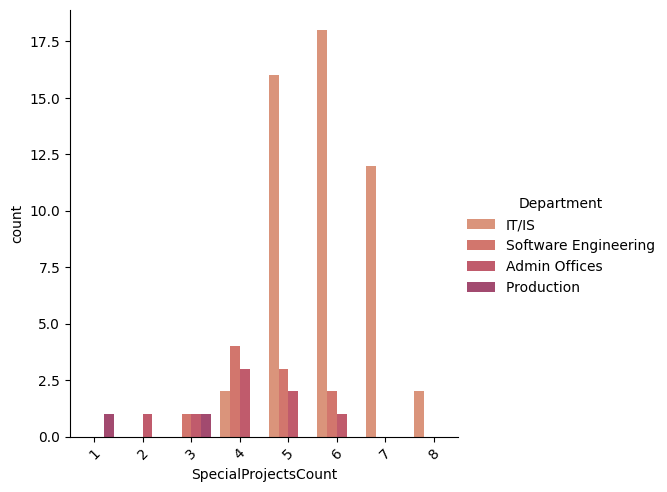

In [113]:
sns.catplot(x= 'SpecialProjectsCount',kind='count',data=df[(df["SpecialProjectsCount"]> 0)] , hue="Department")
plt.xticks(rotation=45)

**Interpretation**
The data shows that the Sales Department has the highest relative proportion for more improvement (Needs Improvement and PIP). In general, the organisation seems to have a good performance review. Also, the interesting highlight is that Sales does not have any Special projects, and the Production Department has only a couple of them. This highlight might indicate the origin of a lack of satisfying evaluation due to motivation levels. This relationship should be further explored.

## Organisation Satisfaction

**What is employees satisfaction and salary across departments?**

(array([0, 1, 2, 3, 4, 5]),
 [Text(0, 0, 'Admin Offices'),
  Text(1, 0, 'Executive Office'),
  Text(2, 0, 'IT/IS'),
  Text(3, 0, 'Production       '),
  Text(4, 0, 'Sales'),
  Text(5, 0, 'Software Engineering')])

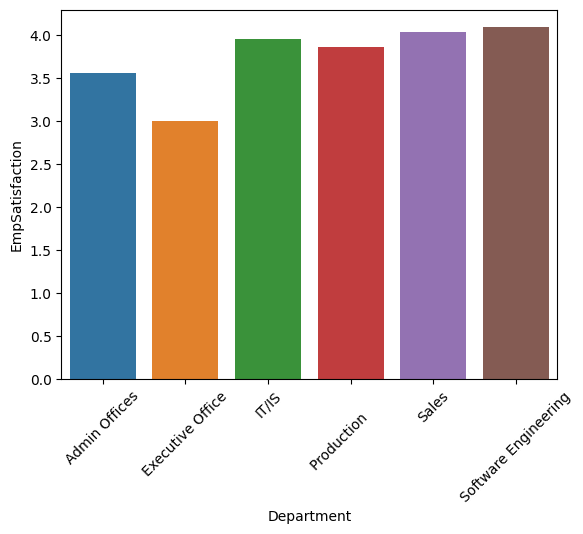

In [61]:
dep_sat = df.groupby('Department')['EmpSatisfaction'].mean().reset_index()
sns.barplot(x='Department',y='EmpSatisfaction',data=dep_sat)
plt.xticks(rotation=45)

(array([0, 1, 2, 3, 4, 5]),
 [Text(0, 0, 'Admin Offices'),
  Text(1, 0, 'Executive Office'),
  Text(2, 0, 'IT/IS'),
  Text(3, 0, 'Production       '),
  Text(4, 0, 'Sales'),
  Text(5, 0, 'Software Engineering')])

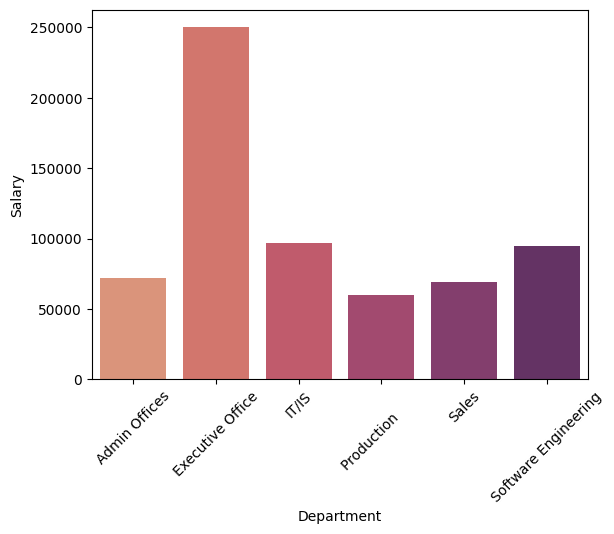

In [105]:
dep_sal = df.groupby('Department')['Salary'].mean().reset_index()
sns.barplot(x='Department',y='Salary',data=dep_sal)
plt.xticks(rotation=45)

**Interpretation** It seems that there is no huge differences in employee satisfaction among departments. Although, Executive Office shows significant drop in satisfaction, in spite of the highest level of salary. Such insight indicates that origin of lower level of satisfaction in Executive Office can be attributed to other factors (for example, higher level of stress, etc.).

**What is the level of employee satisfaction in respect to their performance score and salary?**

(array([0, 1, 2, 3]),
 [Text(0, 0, 'Exceeds'),
  Text(1, 0, 'Fully Meets'),
  Text(2, 0, 'Needs Improvement'),
  Text(3, 0, 'PIP')])

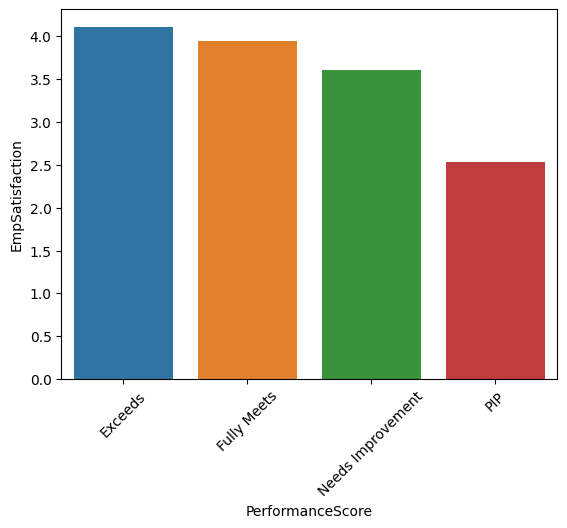

In [64]:
per_sat = df.groupby('PerformanceScore')['EmpSatisfaction'].mean().reset_index()
sns.barplot(x='PerformanceScore',y='EmpSatisfaction',data=per_sat)
plt.xticks(rotation=45)

(array([0, 1, 2, 3]),
 [Text(0, 0, 'Exceeds'),
  Text(1, 0, 'Fully Meets'),
  Text(2, 0, 'Needs Improvement'),
  Text(3, 0, 'PIP')])

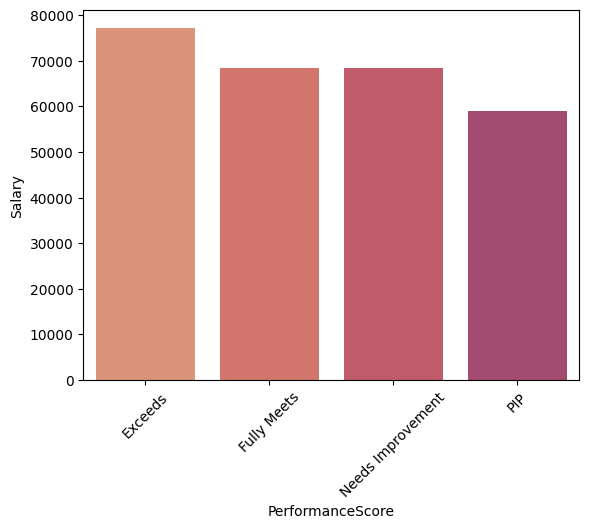

In [106]:
dep_sal = df.groupby('PerformanceScore')['Salary'].mean().reset_index()
sns.barplot(x='PerformanceScore',y='Salary',data=dep_sal)
plt.xticks(rotation=45)

**Interpretation** Evidently, the employees that had lowest performance score also had lowest satisfaction and salary. Such a finding requires a deeper analysis, to seek the casual relation - is low satisfaction and salary causes low performance score or vice versa.

## Counterproductive work behavior

**What is the degree of absenteeism across departments and performance score level?**

(array([0, 1, 2, 3, 4, 5]),
 [Text(0, 0, 'Admin Offices'),
  Text(1, 0, 'Executive Office'),
  Text(2, 0, 'IT/IS'),
  Text(3, 0, 'Production       '),
  Text(4, 0, 'Sales'),
  Text(5, 0, 'Software Engineering')])

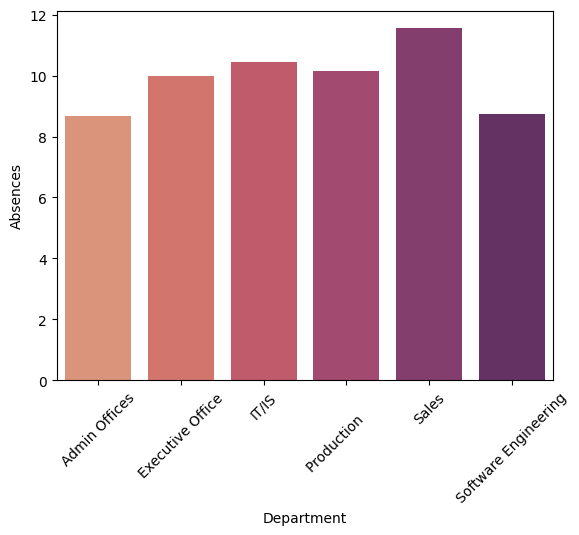

In [117]:
dep_sal = df.groupby('Department')['Absences'].mean().reset_index()
sns.barplot(x='Department',y='Absences',data=dep_sal)
plt.xticks(rotation=45)

(array([0, 1, 2, 3]),
 [Text(0, 0, 'Exceeds'),
  Text(1, 0, 'Fully Meets'),
  Text(2, 0, 'Needs Improvement'),
  Text(3, 0, 'PIP')])

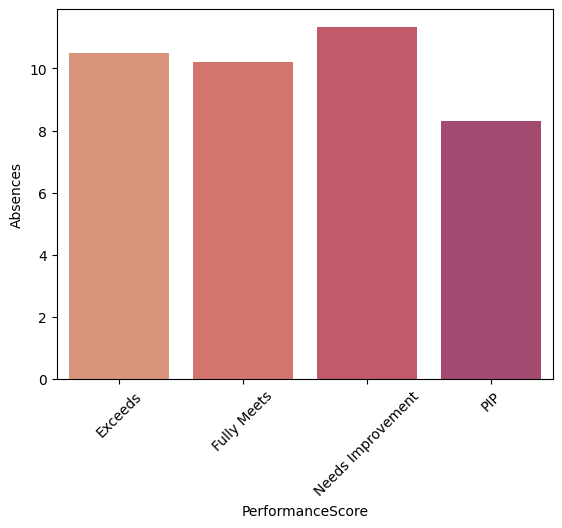

In [118]:
dep_sal = df.groupby('PerformanceScore')['Absences'].mean().reset_index()
sns.barplot(x='PerformanceScore',y='Absences',data=dep_sal)
plt.xticks(rotation=45)

**What is the degree of tardiness across departments and performance score level?**

(array([0, 1, 2, 3, 4, 5]),
 [Text(0, 0, 'Admin Offices'),
  Text(1, 0, 'Executive Office'),
  Text(2, 0, 'IT/IS'),
  Text(3, 0, 'Production       '),
  Text(4, 0, 'Sales'),
  Text(5, 0, 'Software Engineering')])

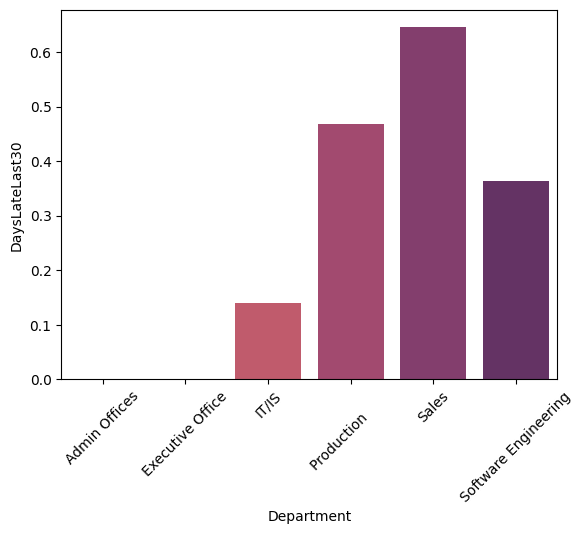

In [120]:
dep_sal = df.groupby('Department')['DaysLateLast30'].mean().reset_index()
sns.barplot(x='Department',y='DaysLateLast30',data=dep_sal)
plt.xticks(rotation=45)

(array([0, 1, 2, 3]),
 [Text(0, 0, 'Exceeds'),
  Text(1, 0, 'Fully Meets'),
  Text(2, 0, 'Needs Improvement'),
  Text(3, 0, 'PIP')])

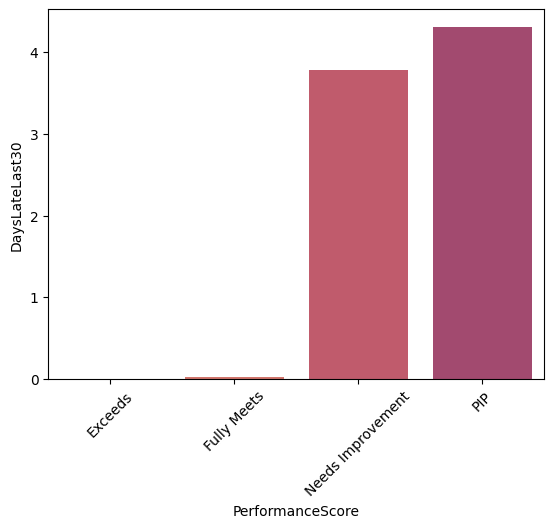

In [121]:
dep_sal = df.groupby('PerformanceScore')['DaysLateLast30'].mean().reset_index()
sns.barplot(x='PerformanceScore',y='DaysLateLast30',data=dep_sal)
plt.xticks(rotation=45)

**Interpretation** Data show that Sales and Production Departments have highest level of counterproductive working behaviour, as well group that have lowest performance score (both departments are highly represented in those groups).

## Conclusion


The analysis of organizational data reveals key insights. The Sales Department shows a notable need for improvement, suggesting potential areas for management attention and motivation enhancement. Conversely, the Executive Office experiences a significant drop in satisfaction despite having the highest salary, indicating the influence of non-monetary factors on job satisfaction. The correlation between low performance scores, lower satisfaction, and salary levels prompts further investigation into causal relationships. Additionally, Sales and Production Departments exhibit higher levels of counterproductive behavior, particularly in groups with lower performance scores, emphasizing the need for targeted strategies to mitigate such behaviors. Overall, these findings provide a foundation for focused interventions to improve organizational performance, employee satisfaction, and well-being.